# Prunning methods

This is a notebook showing how to use different prunning methods on connectomes which are represented by sparse matrices with integer entries representing the number of touches/synapses in a connection. 

In [1]:
from pathlib import Path
import pickle
import numpy as np 

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap
#from conntility import ConnectivityMatrix

In [2]:
# Paths to data  
root=Path("/Users/danielaegas/")/"OneDrive - Open Brain Institute"/"Human_Connectivity_Paper"/"conn_matrix" #Change root to OneDrive location in your local machine
fnames= {"structural":{"rat":
                       "Rat_623um_squared_struc_conmat_filtered_compressed.h5",
                       "human":
                       "Human_NEWstruct_conmat_filtered_compressed.h5"},
         "functional":{"rat":
                       "Rat_623um_squared_funct_conmat_filtered_compressed.h5",
                       "human":
                       "Human_NEWfunct_conmat_filtered_compressed.h5"}}

## Compute intersection stats

In [3]:
# Load intersections and unions 
animals=["rat", "human"]
#animals=["rat"]
intersection_functionals={}
intersectionss={}
union_functionals={}
unions={}
for animal in animals: 
    path_in=f"{root}/mat_intersection/intersections_with_funct_{animal}.pkl"
    with open(path_in, "rb") as f:
        intersection_functionals[animal] = pickle.load(f)
    
    path_in=f"{root}/mat_intersection/intersections_across_controls_{animal}.pkl"
    with open(path_in, "rb") as f:
        intersectionss[animal] = pickle.load(f)

    path_in=f"{root}/mat_intersection/union_with_funct_{animal}.pkl"
    with open(path_in, "rb") as f:
        union_functionals[animal] = pickle.load(f)
    
    path_in=f"{root}/mat_intersection/union_across_controls_{animal}.pkl"
    with open(path_in, "rb") as f:
        unions[animal] = pickle.load(f)

# Compute stats of intersection and union sizes
iou_stats={}
iou_stats_functional={}
for animal in animals:
    iou_stats[animal], iou_stats_functional[animal]={},{}
    df=pd.DataFrame.from_dict(intersectionss[animal]).divide(pd.DataFrame.from_dict(unions[animal])).drop((0,0)) #Jaccard similarity all samples but drop comparable with itself
    iou_stats[animal].update({"all": df, "mean": df.mean(axis=0), "sem": df.sem(axis=0)})
    df=pd.DataFrame(intersection_functionals[animal]).divide(pd.DataFrame(union_functionals[animal])) #Jaccard similarity to functional al samples
    iou_stats_functional[animal].update({"all": df, "mean": df.mean(axis=0), "sem": df.sem(axis=0)})



## Plotting

In [4]:
# Plotting specs
my_cmap = LinearSegmentedColormap.from_list('my_gradient', (# cmap provided by Natali
    (0.000, (0.855, 0.969, 0.965)),
    (0.250, (0.020, 0.918, 0.863)),
    (0.500, (0.027, 0.678, 0.678)),
    (0.750, (0.000, 0.502, 0.502)),
    (1.000, (0.055, 0.376, 0.376))))

cmaps={"human":my_cmap, 
       "rat": "Purples"}
colors={"human":"teal",
        "rat":"blueviolet"}

#figize=

### Jaccard similarity

We plot the mean values of the Jaccard similarity to see how much the identities of the connections is manatined across prunnings as and also the sem across samples to asses variability 

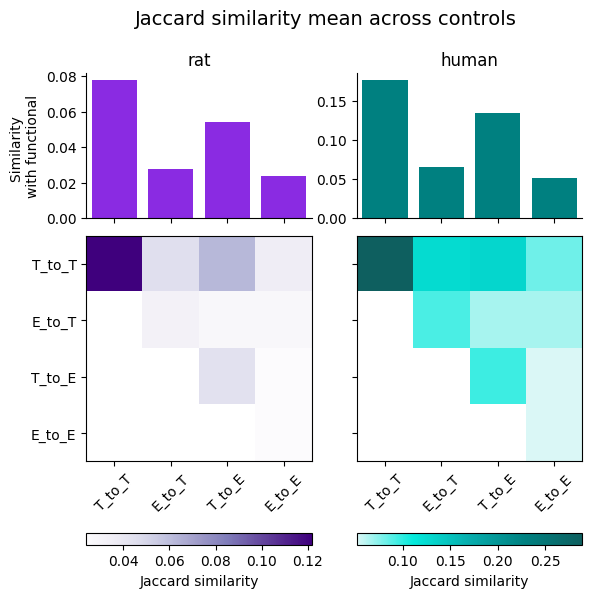

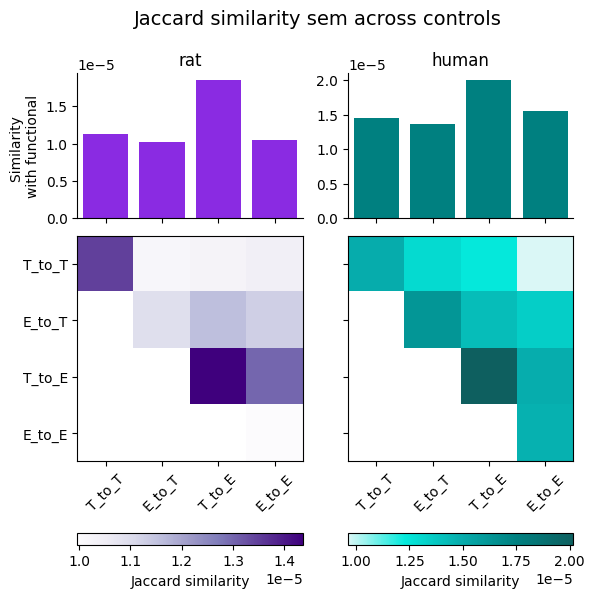

In [27]:
prune_order=["T_to_T", "E_to_T", "T_to_E", "E_to_E"]
for metric in ["mean", "sem"]:
    fig,axs = plt.subplots(2,2, sharex=True, gridspec_kw={'height_ratios': [1, 3]}, figsize=(6.4,6.4))
    fig.suptitle(f"Jaccard similarity {metric} across controls", fontsize=14)
    for j, animal in enumerate(["rat", "human"]):
        axs[0,j].set_title(animal)

        iou=iou_stats[animal][metric]
        iou=iou.unstack().loc[prune_order, prune_order]
        
        # Bar plots 
        i=0
        df=iou_stats_functional[animal][metric]
        axs[i,j].bar(x=np.arange(df.size), height=df, color=colors[animal])
        axs[i,j].spines[["top", "right"]].set_visible(False)
        axs[i,0].set_ylabel("Similarity \nwith functional")
        
        
        # Heat maps 
        i=1
        plot=axs[i,j].imshow(iou, cmap=cmaps[animal])
        cbar_ax = inset_axes(axs[i,j], width="100%", height="5%", loc="lower center", borderpad=-6)
        plt.colorbar(plot, cax=cbar_ax, orientation="horizontal", shrink=0.9, label="Jaccard similarity")
        axs[i,j].set_aspect('equal', adjustable='box')
        axs[i,j].set_xticks(ticks=range(iou.shape[0]),
                        labels=iou.index,
                        rotation=45)
        axs[i,0].set_yticks(ticks=range(iou.shape[0]),
                        labels=iou.index,
                        rotation=0)
        axs[i,1].set_yticks(ticks=range(iou.shape[0]),
                        labels=[""]*iou.shape[0],
                        rotation=0)
        plt.subplots_adjust(hspace=-.3)
        fig.savefig(f"figures/Jaccard_similarity_{metric}.pdf", dpi=300, transparent=True)
        fig.savefig(f"figures/Jaccard_similarity_{metric}.png", dpi=300, bbox_inches="tight", transparent=True)
        fig.savefig(f"figures/Jaccard_similarity_{metric}.svg", dpi=300, transparent=True)
    